<a href="https://colab.research.google.com/github/sandeepkhadk/Data-Piepline/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
path='/content/drive/MyDrive/Data_Pipeline/Transformed_Airline_Delay_Cause.csv'

In [78]:
df = pd.read_csv(path)

In [79]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,nas_delay,security_delay,late_aircraft_delay,total_delay,carrier_delay_pct,weather_delay_pct,nas_delay_pct,security_delay_pct,late_aircraft_delay_pct,quarter
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,118.0,0.0,425.0,1375.0,0.051636,0.553455,0.085818,0.0,0.309091,3
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,62.0,0.0,518.0,799.0,0.272841,0.001252,0.077597,0.0,0.648310,3
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,78.0,0.0,444.0,766.0,0.073107,0.245431,0.101828,0.0,0.579634,3
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,388.0,0.0,218.0,1397.0,0.337151,0.229062,0.277738,0.0,0.156049,3
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,134.0,0.0,768.0,1530.0,0.410458,0.000000,0.087582,0.0,0.501961,3


# **CORRELATION MATRIX HEATMAP**

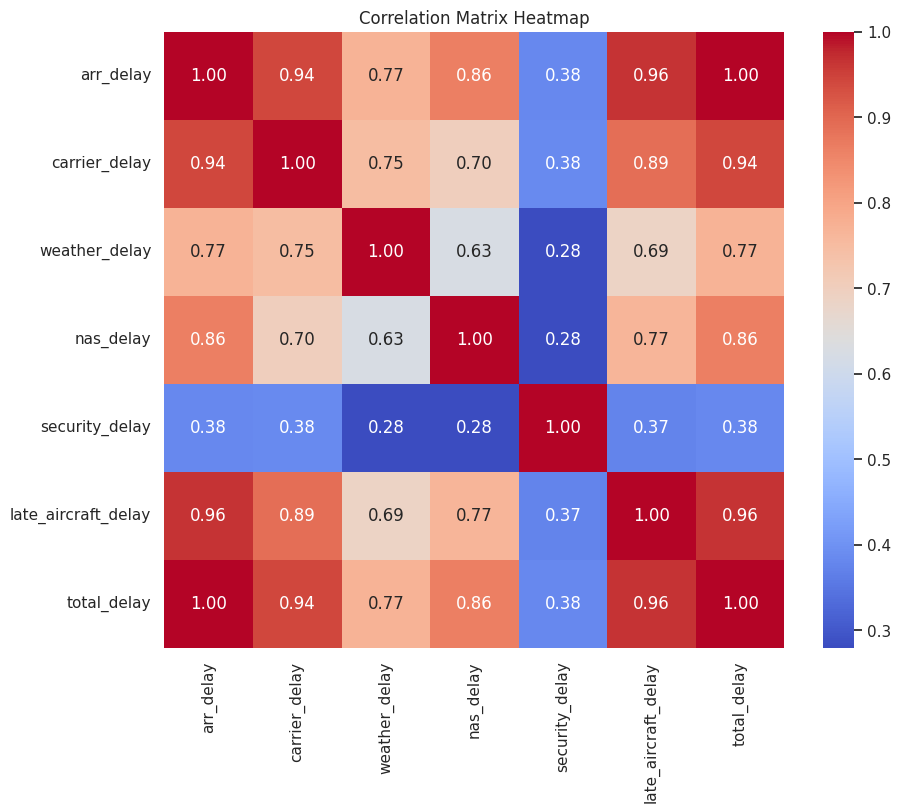

In [80]:
important_cols = [
    'arr_delay','carrier_delay','weather_delay',
    'nas_delay','security_delay','late_aircraft_delay',
    'total_delay'
]

plt.figure(figsize=(10,8))

sns.heatmap(df[important_cols].corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")


plt.title("Correlation Matrix Heatmap")
plt.show()


# Correlation Matrix Heatmap Explanation


*   Arrival delay and total delay have a perfect positive correlation (1.00), meaning total delay increases directly with arrival delay.

*  Late aircraft delay (0.96) and carrier delay (0.94) show strong positive correlations with total flight delay, making them major contributing factors.

*   Late aircraft delay (0.96) and carrier delay (0.94) show strong positive correlations with total flight delay, making them major contributing factors.

*   NAS delay (0.86) has a strong positive correlation with total delay and significantly affects flight delays.

*   Weather delay (0.77) shows a moderate positive correlation with total delay and also contributes to flight delays.

*   Security delay has weak correlations (~0.28–0.38) with arrival delay, carrier delay, late aircraft delay, NAS delay, weather delay, and total flight delay, indicating minimal impact.


# **HISTOGRAM**

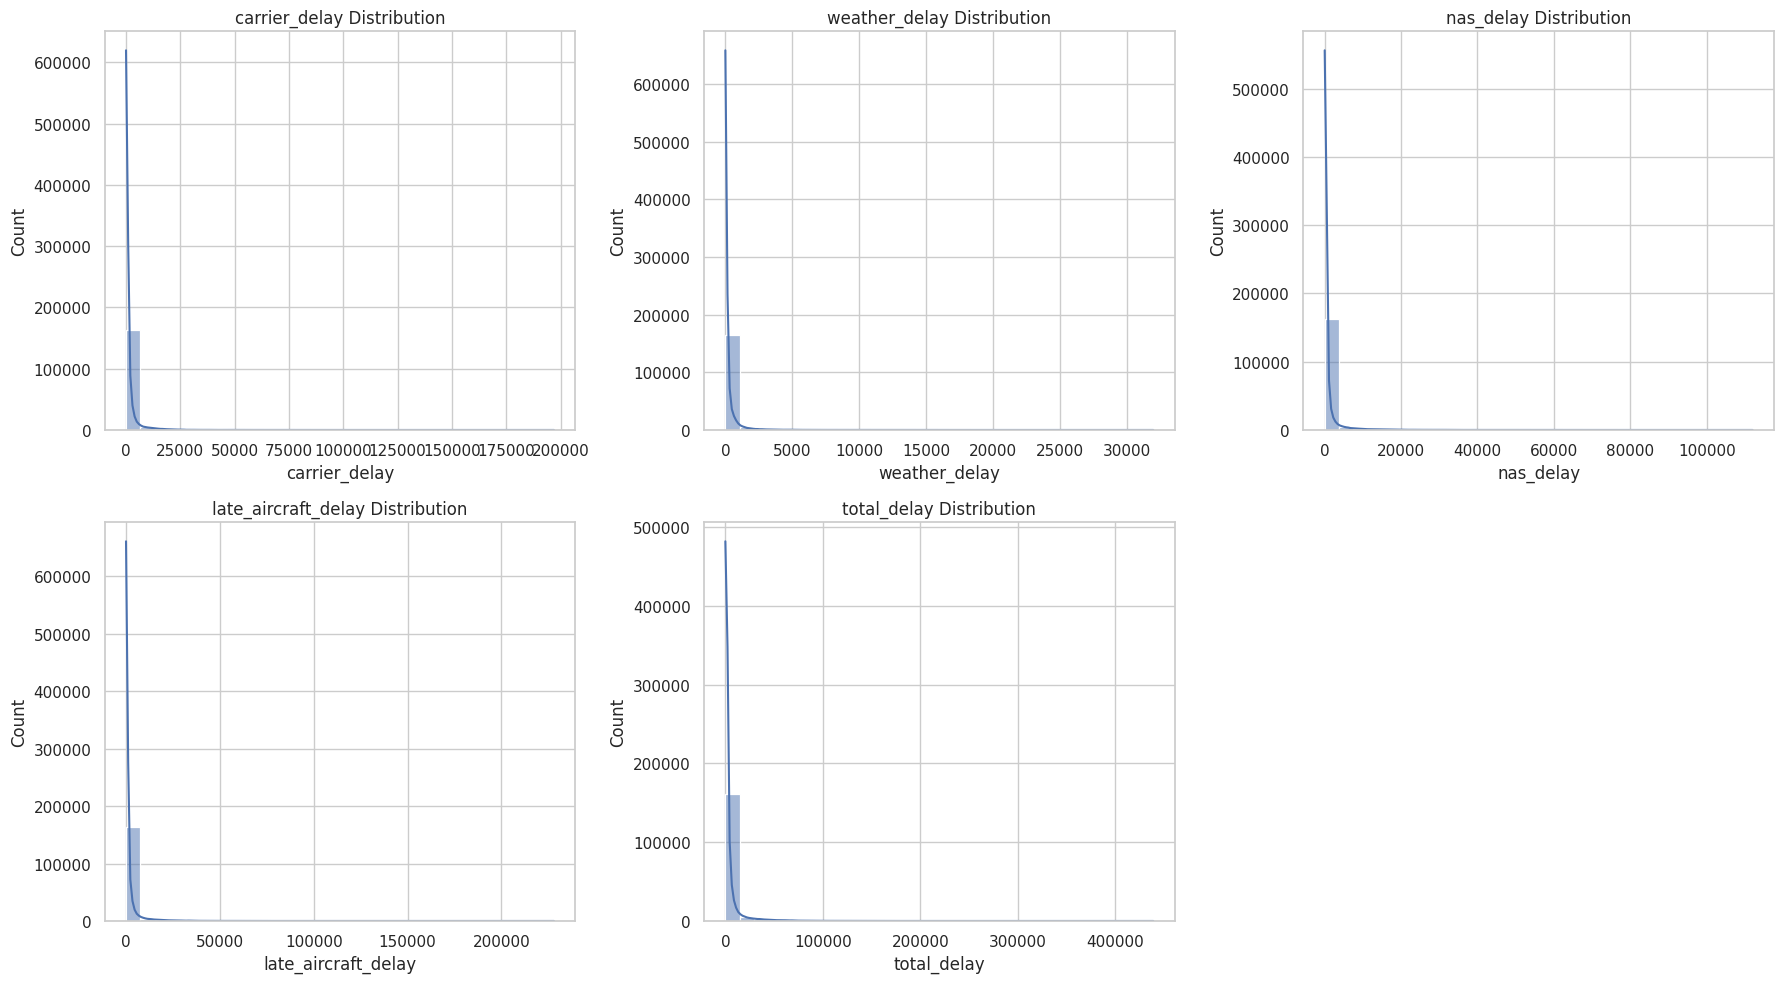

In [81]:
delay_columns = [
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'late_aircraft_delay',
    'total_delay'
]

n_cols = 3
n_rows = int(np.ceil(len(delay_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*5))
axes = axes.flatten()

for i, col in enumerate(delay_columns):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

# Hide any remaining empty axes
for j in range(len(delay_columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

The distribution of  delay is positively skewed with a long right tail, indicating that while most airports experience moderate delays, a small number of airports exhibit extremely high delays. Log transformation improves visualization and highlights the underlying distribution pattern.

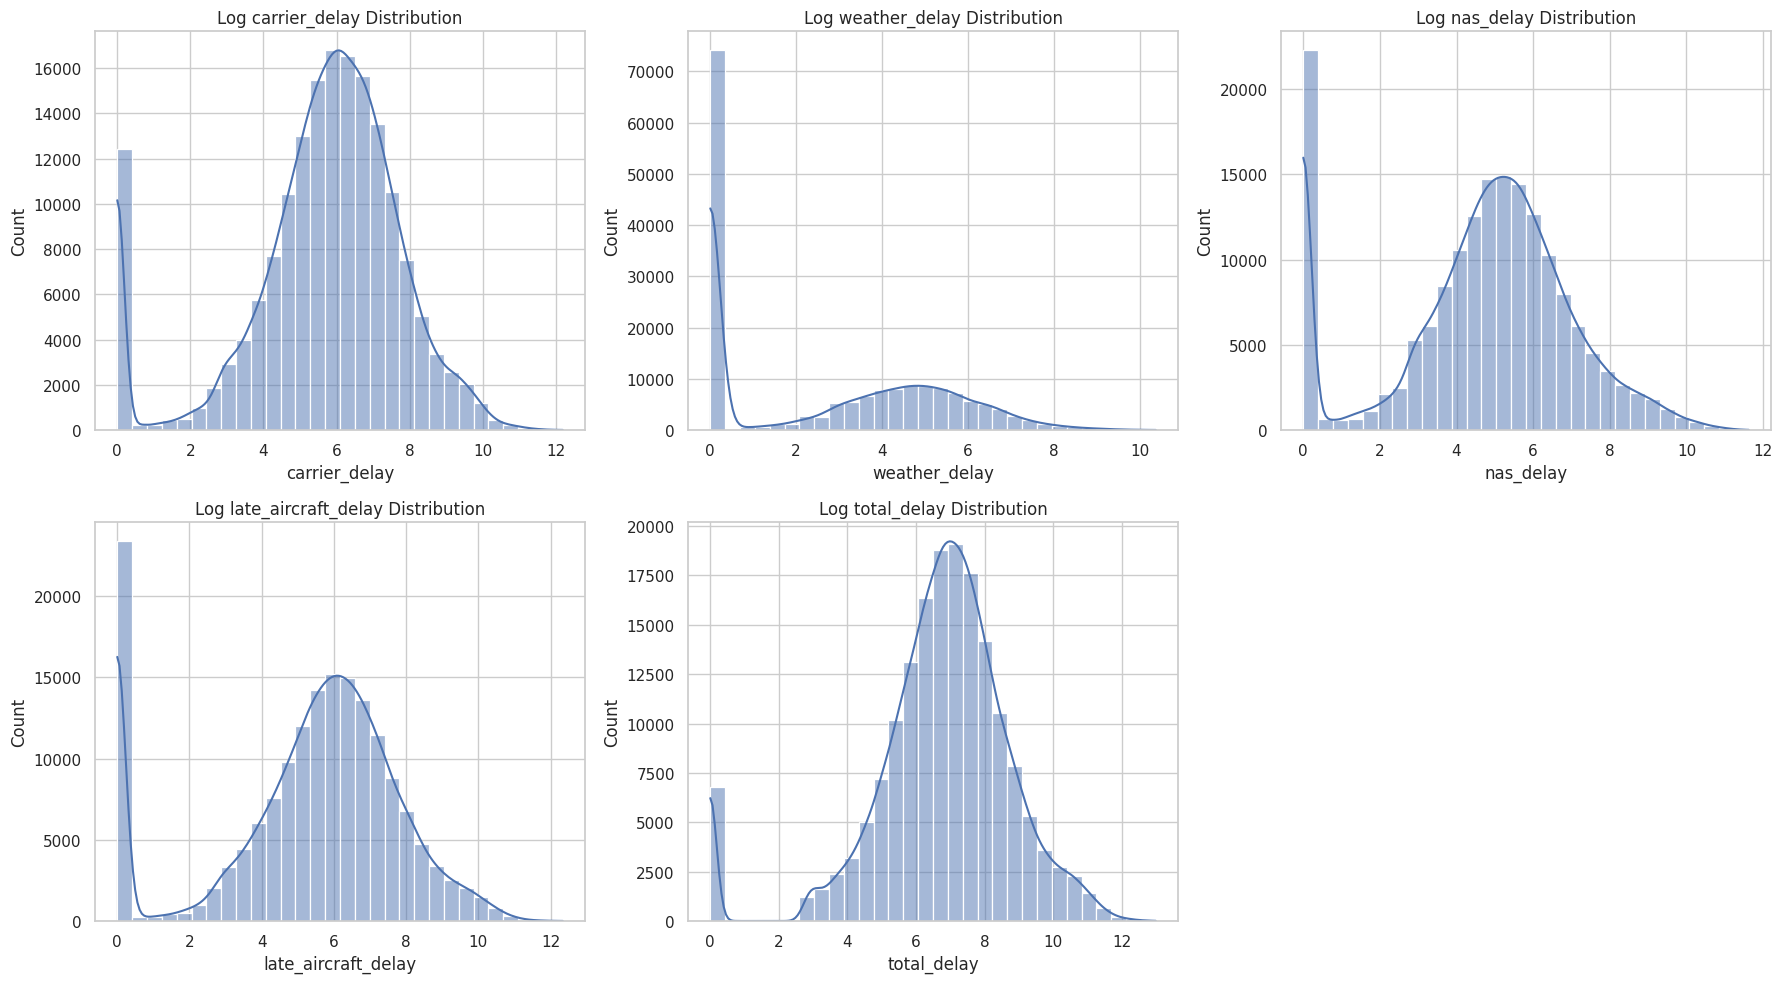

In [82]:
n_cols = 3
n_rows = int(np.ceil(len(delay_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*5))
axes = axes.flatten()

for i, col in enumerate(delay_columns):
    sns.histplot(np.log1p(df[col]), kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Log {col} Distribution")

# Hide any remaining empty axes
for j in range(len(delay_columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [83]:
data = {
    "Delay Type": ["Carrier Delay", "Weather Delay", "NAS & Late Aircraft", "Total Delay"],
    "Observation": [
        "Shows a very clean, symmetrical bell curve for those flights that are delayed.",
        "Has the lowest frequency of occurrences (the curve is shorter and flatter).",
        "These look very similar, suggesting they follow a similar statistical pattern.",
        "This is the 'cleanest' normal distribution, following the Central Limit Theorem."
    ]
}

df1 = pd.DataFrame(data)
display(df1)

,Delay Type,Observation
0,Carrier Delay,"Shows a very clean, symmetrical bell curve for..."
1,Weather Delay,Has the lowest frequency of occurrences (the c...
2,NAS & Late Aircraft,"These look very similar, suggesting they follo..."
3,Total Delay,"This is the 'cleanest' normal distribution, fo..."


# **BOX PLOT**

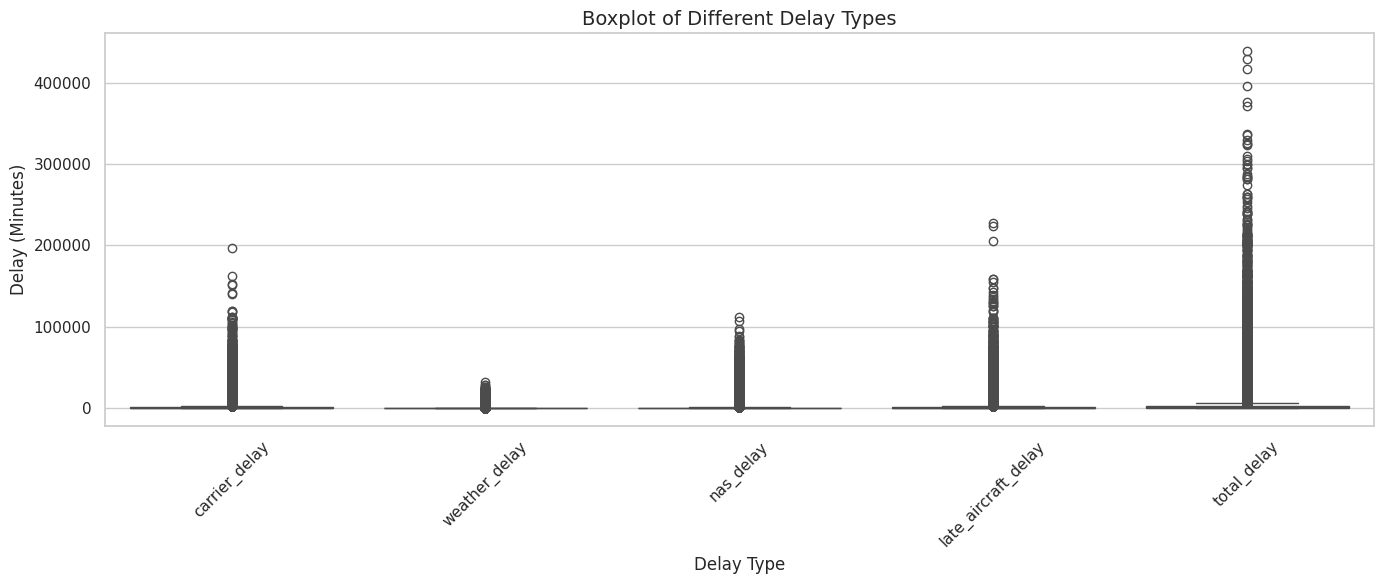

In [84]:
# Convert wide → long format
delay_long = df[delay_columns].melt(
    var_name="Delay_Type",
    value_name="Delay_Minutes"
)

plt.figure(figsize=(14,6))

sns.boxplot(
    data=delay_long,
    x="Delay_Type",
    y="Delay_Minutes"
)

plt.xticks(rotation=45)
plt.title("Boxplot of Different Delay Types", fontsize=14)
plt.xlabel("Delay Type")
plt.ylabel("Delay (Minutes)")

plt.tight_layout()
plt.show()

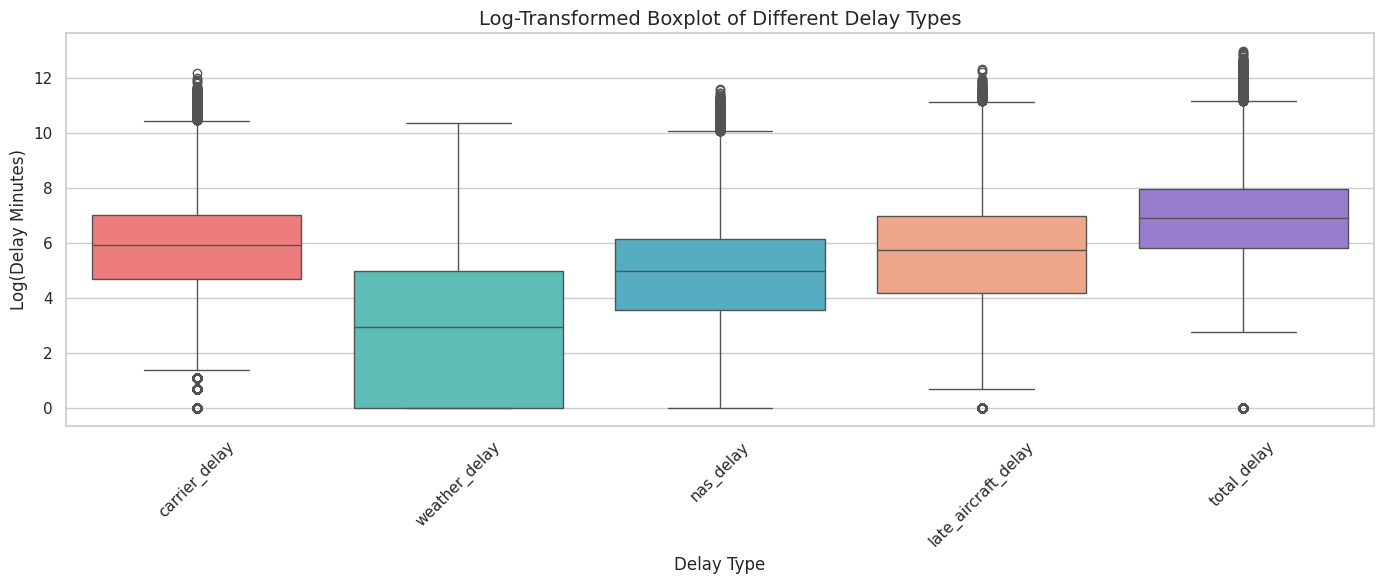

In [85]:

# Convert wide → long format
delay_long = df[delay_columns].melt(
    var_name="Delay_Type",
    value_name="Delay_Minutes"
)

# log transform for better visualization
delay_long["Log_Delay"] = np.log1p(delay_long["Delay_Minutes"])

# Custom palette
palette = {
    col: color for col, color in zip(
        delay_columns,
        ["#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A", "#9370DB"]
    )
}

plt.figure(figsize=(14,6))

sns.boxplot(
    data=delay_long,
    x="Delay_Type",
    y="Log_Delay",
    hue="Delay_Type",
    palette=palette,
    dodge=False,
    legend=False
)

plt.xticks(rotation=45)
plt.title("Log-Transformed Boxplot of Different Delay Types", fontsize=14)
plt.xlabel("Delay Type")
plt.ylabel("Log(Delay Minutes)")

plt.tight_layout()
plt.show()


# **Key Insights from the Box Plots**

**1. Skewness & Outliers:** The original scale shows extreme right-skewness, where a few delays exceed 400,000 minutes, making the "typical" delay invisible.

**2. Total Delay:** This category consistently has the highest median and most frequent extreme outliers across both scales.

**3. Weather Delays:** These have the lowest median but the highest relative variability (largest box size on the log scale), indicating they are infrequent but unpredictable.

**4. Systemic Consistency:** Carrier, NAS, and Late Aircraft delays show very similar median values (around 5–6 on the log scale), suggesting they are the primary "routine" drivers of wait times.


# **Why Use Log Transformation ?**

**1. Visibility:** In the original plot, the 25th–75th percentile boxes are flattened to the bottom. Log-scaling "stretches" the lower values so we can actually see the median and quartiles.

**2. Scale Compression:** It reduces the y-axis from a 400,000-unit range to a ~13-unit range, preventing a single "black swan" event from ruining the chart's readability.

**3. Comparability:** It allows for a side-by-side comparison of different delay types that would otherwise all look like flat lines at zero on a linear scale.

# **LINE PLOT**

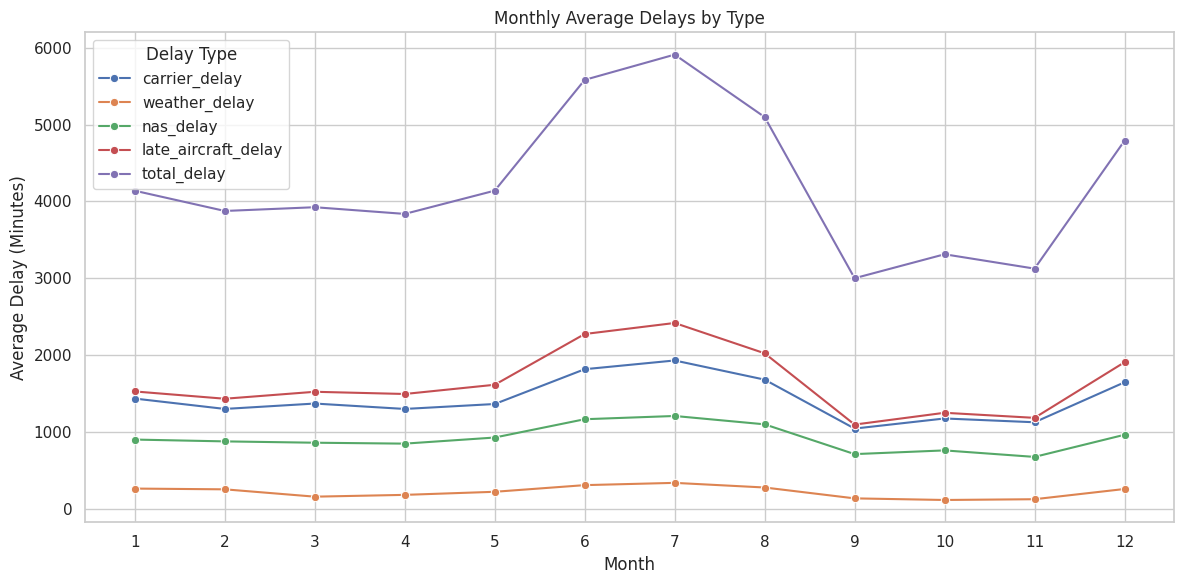

In [86]:
plt.figure(figsize=(12,6))

# Aggregate by month
monthly_delay = df.groupby("month")[delay_columns].mean().reset_index()

# Melt so each delay type is a row for seaborn
monthly_melted = monthly_delay.melt(id_vars="month",
                                    value_vars=delay_columns,
                                    var_name="Delay Type",
                                    value_name="Average Delay")

# Plot
sns.lineplot(
    data=monthly_melted,
    x="month",
    y="Average Delay",
    hue="Delay Type",
    marker="o"
)

plt.title("Monthly Average Delays by Type")
plt.xlabel("Month")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(range(1,13))
plt.grid(True)
plt.legend(title="Delay Type")
plt.tight_layout()
plt.show()

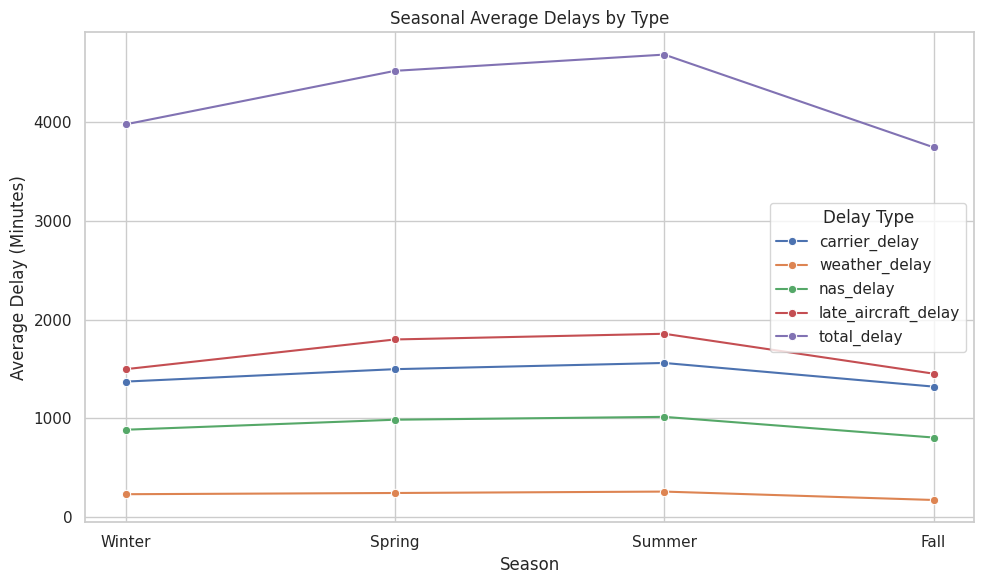

In [87]:
plt.figure(figsize=(10,6))

# Map quarter to season
season_map = {1: "Winter", 2: "Spring", 3: "Summer", 4: "Fall"}
df['season'] = df['quarter'].map(season_map)

# Aggregate by season
seasonal_delay = df.groupby("season")[delay_columns].mean().reindex(["Winter", "Spring", "Summer", "Fall"]).reset_index()

# Melt for seaborn
seasonal_melted = seasonal_delay.melt(id_vars="season",
                                      value_vars=delay_columns,
                                      var_name="Delay Type",
                                      value_name="Average Delay")

# Plot
sns.lineplot(
    data=seasonal_melted,
    x="season",
    y="Average Delay",
    hue="Delay Type",
    marker="o"
)

plt.title("Seasonal Average Delays by Type")
plt.xlabel("Season")
plt.ylabel("Average Delay (Minutes)")
plt.grid(True)
plt.legend(title="Delay Type")
plt.tight_layout()
plt.show()

# **Monthly & Seasonal Trend Insights**

**1. Seasonal Peaks:** Delays clearly spike during the Summer months (June–July) and December, likely due to increased travel volume and seasonal weather(rain & strome).

**2. Primary Drivers:** late_aircraft_delay and carrier_delay are the top two individual contributors to the monthly averages, following the same seasonal pattern as the total_delay.

**3. Stability of Weather:** Despite its unpredictable nature in individual cases, weather_delay remains the lowest and most stable average contributor month to month.

# **PIE CHART**

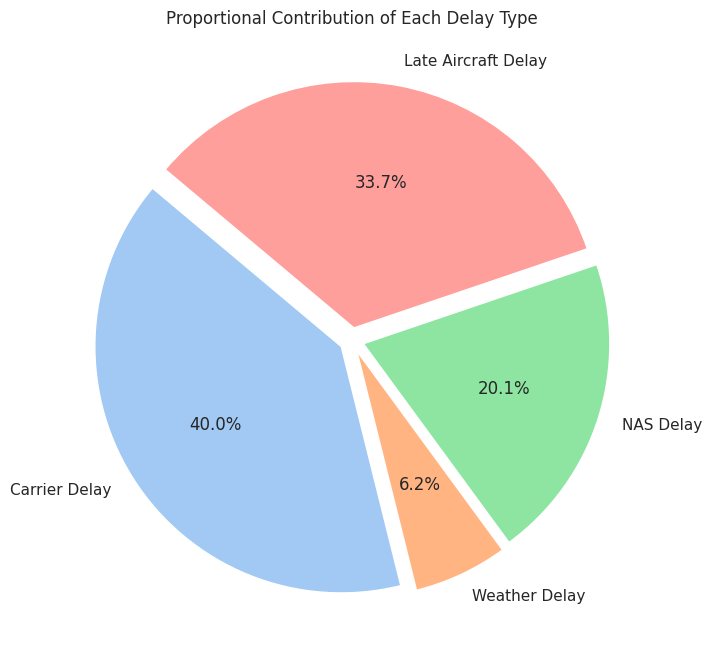

In [88]:
# Delay ratio..
all_delay_ratio = [
    'carrier_delay_pct',
    'weather_delay_pct',
    'nas_delay_pct',
    'late_aircraft_delay_pct'
]

# Calculate the sum of each delay type
delay_sums = df[all_delay_ratio].sum()

# Updated list with clean labels
clean_labels = ['Carrier Delay', 'Weather Delay', 'NAS Delay', 'Late Aircraft Delay']

plt.figure(figsize=(10, 8))
plt.pie(
    delay_sums,
    labels=clean_labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel'),
    explode=[0.05] * len(delay_sums)
)

plt.title("Proportional Contribution of Each Delay Type")
plt.show()

# **Proportional Impact (Pie Chart)**

**1. Main Contributor:** Carrier Delays represent the largest piece of the pie at 40.0%, followed closely by Late Aircraft Delays at 33.7%.

**2. Operational vs External:** Combined, carrier-controlled and late aircraft issues account for nearly 74% of all delay minutes, suggesting internal operations are the primary area for improvement.

**3. Weather's Role:** Despite its high unpredictability in individual cases, Weather only accounts for 6.2% of the total proportional delay minutes.

# **CONCLUSION**

The analysis reveals that flight delays are primarily an operational and
logistical challenge rather than an environmental one. While weather creates
significant outliers, the vast majority of delay minutes are generated by Carrier-level issues and the propagation effects (Late Aircraft) of a tight flight schedule. Efforts to improve on-time performance should focus on increasing operational buffers and improving carrier logistics, particularly during high-volume summer months.